<a href="https://colab.research.google.com/github/anmolanand0207-cpu/Global-Superstore/blob/main/EDA_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#

df = pd.read_csv('/content/g_store.csv', encoding = 'latin')
df.head(2)

df.shape
df.isna().sum()

# since postal code has 41296 null values and it is irrelevant for further analysis as we have othe rreq details already so it is better to drop this col form dataset

df.drop(['Postal Code', 'Row ID'], axis = 1)



# We are utilising First-Principle approaches in which the business questions are defined prior to analysis

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df.dtypes


df.index.name = 'S.NO.'
df['Lead Time(in days)'] = (df['Ship Date'] - df['Order Date']).dt.days

df.drop('Row ID', axis = 1, inplace = True)

total_duplicates = df.duplicated().sum()
print(f"Total number of duplicate rows: {total_duplicates}")

#Since no duplicate rows are found so no need to delete any row for anlaysis







/tmp/ipykernel_948/1436844739.py:22: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Order Date'] = pd.to_datetime(df['Order Date'])
/tmp/ipykernel_948/1436844739.py:23: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Ship Date'] = pd.to_datetime(df['Ship Date'])


Total number of duplicate rows: 0


In [2]:
df.head(5)

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Lead Time(in days)
S.NO.,,,,,,,,,,,,,,,,,,,,,
0,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,United States,...,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical,0
1,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,...,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical,2
2,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,Australia,...,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium,1
3,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,Germany,...,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium,2
4,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,Senegal,...,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical,1


/tmp/ipykernel_948/2785037126.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=segment_summary, x='Segment', y='Total_Revenue', ax=axes[0], palette='Blues_d')
/tmp/ipykernel_948/2785037126.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(data=segment_summary, x='Segment', y='Profit_Margin_%', ax=axes[1], palette='Greens_d')


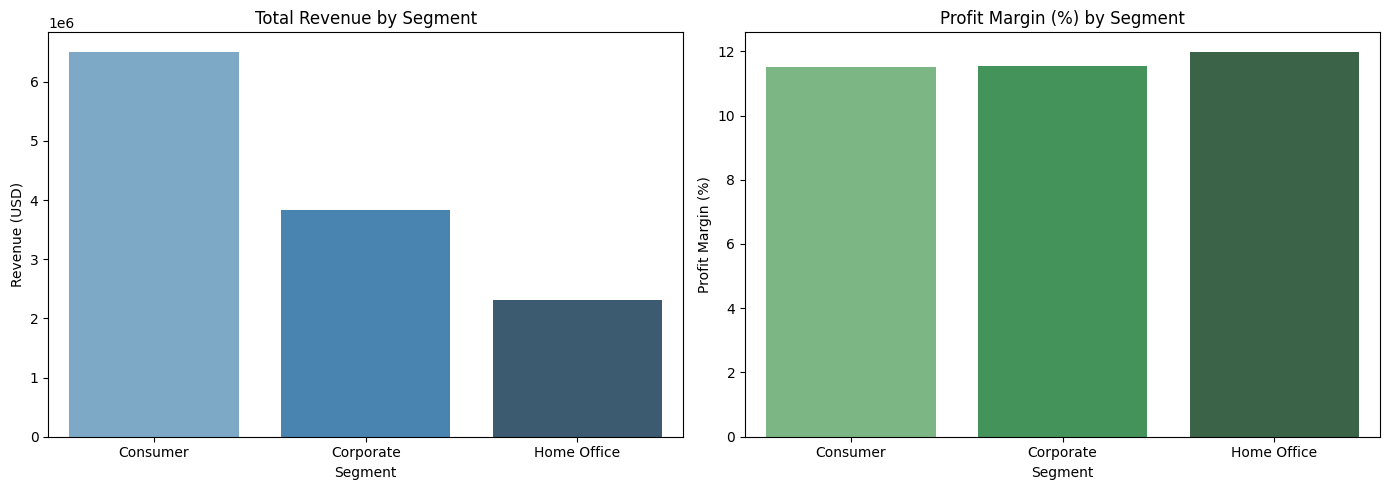

In [3]:
# segment wise analysis:-
df['Is_Loss'] = df['Profit'] < 0
df['Loss Amount'] = df['Profit'].apply(lambda x : abs(x) if x < 0 else 0)

g1 = df.groupby('Segment')
segment_summary = g1.agg(
    Total_Revenue=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Quantity_Sold=('Quantity', 'sum'),
    Unique_Customers=('Customer ID', 'nunique'),
    Distinct_Orders=('Order ID', 'nunique'),
    Total_Loss_Amount =('Loss Amount', 'sum'),
    Loss_Order_Count = ('Is_Loss', 'sum'),
    Avg_Loss_Amount = ('Loss Amount', 'mean'),
    Avg_Discount_Amount = ('Discount', 'mean'),
    Avg_Lead_Time = ('Lead Time(in days)', 'mean'),
    Total_Shipping_Cost = ('Shipping Cost', 'sum')
).reset_index()

segment_summary

#Important Metrics that will be useful  in comparative anlaysis of segment are as follows :-

segment_summary['AOV'] = segment_summary['Total_Revenue'] / segment_summary['Distinct_Orders']
segment_summary['ARPC'] = segment_summary['Total_Revenue'] / segment_summary['Unique_Customers']
segment_summary['Profit_Margin_%'] = (segment_summary['Total_Profit'] / segment_summary['Total_Revenue'])*100
segment_summary['Orders_Per_Customer'] = segment_summary['Distinct_Orders'] / segment_summary['Unique_Customers']
segment_summary['Shipping_Cost_Per_Order'] = segment_summary['Total_Shipping_Cost'] / segment_summary['Distinct_Orders']
segment_summary['Avg_Shipping_Cost_Per_Customer'] = segment_summary['Total_Shipping_Cost'] / segment_summary['Unique_Customers']
segment_summary = segment_summary.round(2)
segment_summary

# For clear visualisations :-

fig, axes = plt.subplots(1, 2, figsize=(14, 5)) # Create the canvas

# Plot 1
ax1 = sns.barplot(data=segment_summary, x='Segment', y='Total_Revenue', ax=axes[0], palette='Blues_d')
ax1.set(title='Total Revenue by Segment', ylabel='Revenue (USD)')

# Plot 2
ax2 = sns.barplot(data=segment_summary, x='Segment', y='Profit_Margin_%', ax=axes[1], palette='Greens_d')
ax2.set(title='Profit Margin (%) by Segment', ylabel='Profit Margin (%)')

plt.tight_layout()
plt.show()




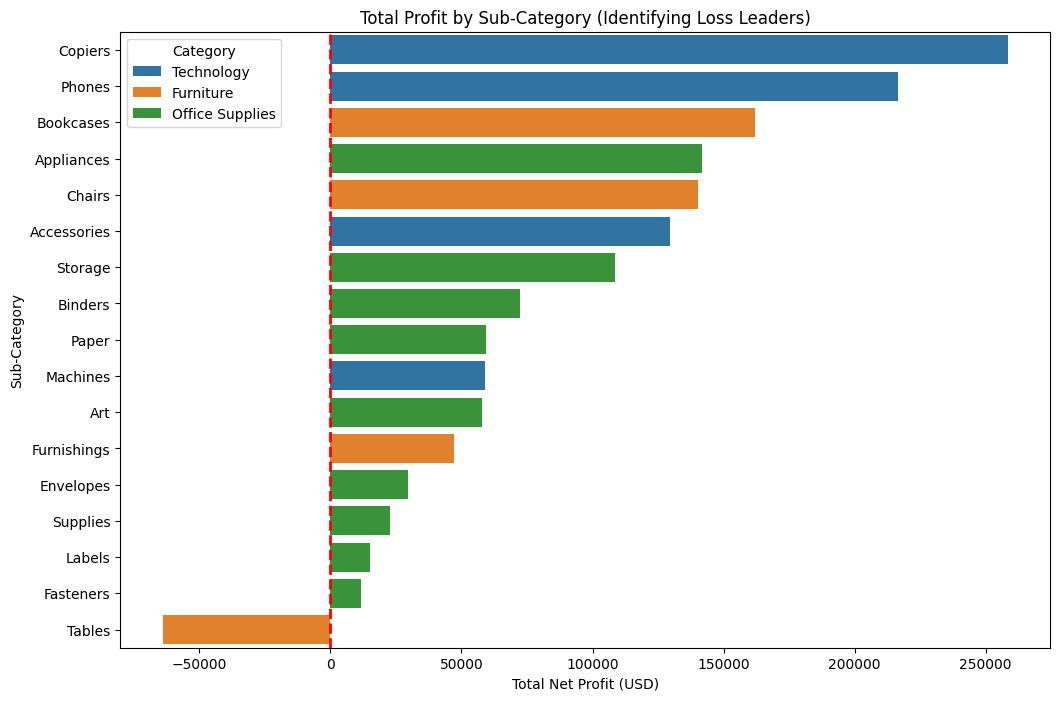

In [4]:
# CATEGORY WISE ANALYSIS:-
# Category Summary
g2 = df.groupby(['Category', 'Sub-Category'])
category_summary = g2.agg(
    Total_Revenue=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Loss_Order_Count=('Is_Loss', 'sum'),
    Avg_Discount=('Discount', 'mean')
).reset_index()

category_summary['Profit_Margin_%'] = (category_summary['Total_Profit'] / category_summary['Total_Revenue']) * 100
category_summary = category_summary.sort_values(by='Total_Profit', ascending=False).round(2)
 # VISUALISTION FRO BETTER UNDERSTANDING
plt.figure(figsize=(12, 8))

# Create the Seaborn barplot
ax = sns.barplot(data=category_summary, x='Total_Profit', y='Sub-Category', hue='Category', dodge=False)

# Use Seaborn's ax.set() to label everything cleanly
ax.set(title='Total Profit by Sub-Category (Identifying Loss Leaders)',
       xlabel='Total Net Profit (USD)',
       ylabel='Sub-Category')

# Reference line for zero profit
ax.axvline(0, color='red', linestyle='--', linewidth=2)

plt.show()





/tmp/ipykernel_948/1691312983.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=region_summary, x='Region', y='Profit_Margin_%', palette='coolwarm')


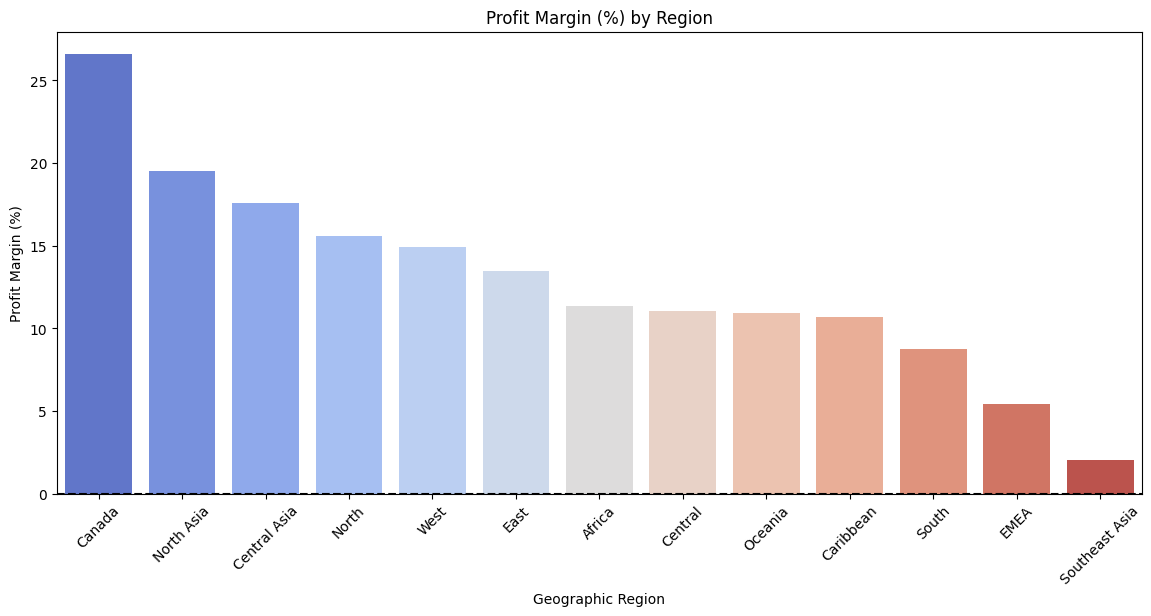

/tmp/ipykernel_948/1691312983.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_summary, x='Region', y='Avg_Lead_Time', palette='Blues_d')


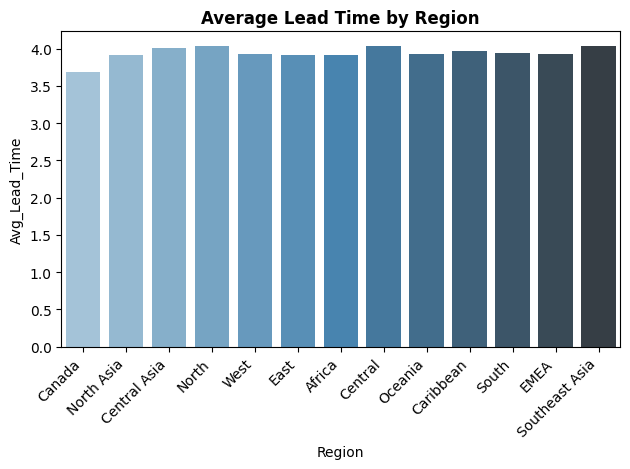

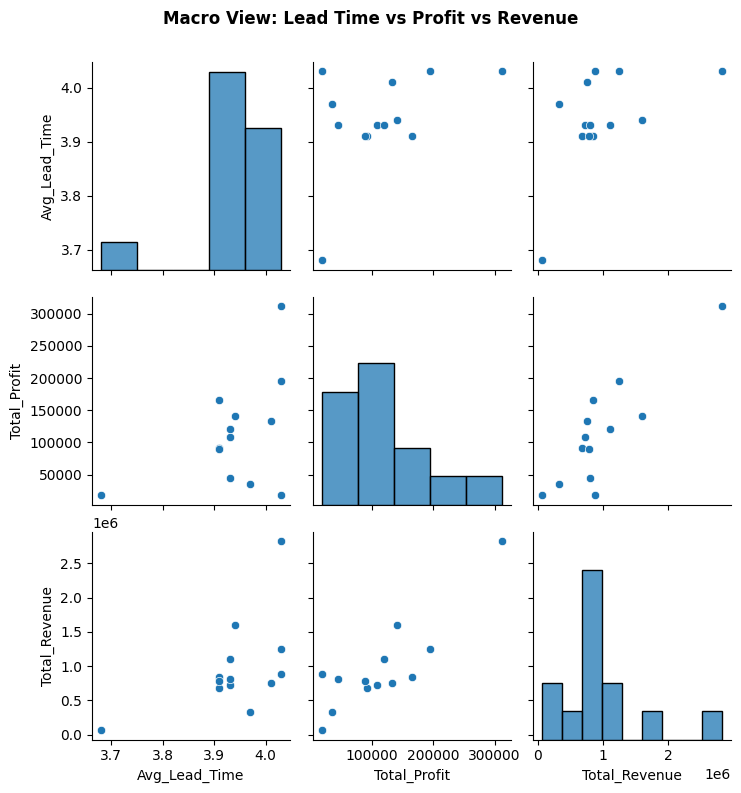

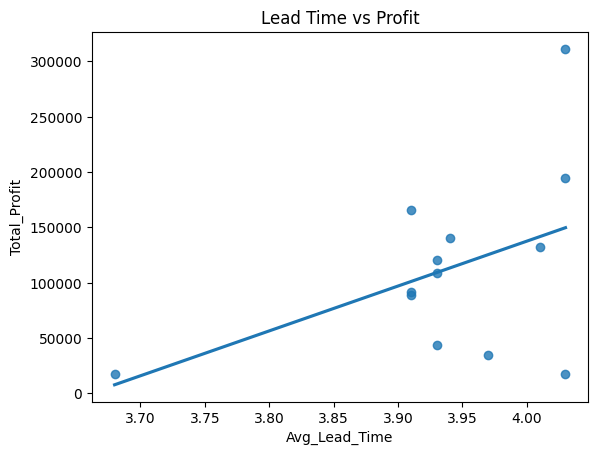

In [5]:
# REGION WISE ANALYSIS:-

# Region Summary
g3 = df.groupby('Region')
region_summary = g3.agg(
    Total_Revenue=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Shipping_Cost=('Shipping Cost', 'sum'),
    Avg_Lead_Time = ('Lead Time(in days)', 'mean')
).reset_index()

region_summary['Profit_Margin_%'] = (region_summary['Total_Profit'] / region_summary['Total_Revenue']) * 100
region_summary = region_summary.sort_values(by='Profit_Margin_%', ascending=False).round(2)

plt.figure(figsize=(14, 6))

ax = sns.barplot(data=region_summary, x='Region', y='Profit_Margin_%', palette='coolwarm')

# Labeling using ax.set()
ax.set(title='Profit Margin (%) by Region',
       xlabel='Geographic Region',
       ylabel='Profit Margin (%)')

# Rotate x-axis labels using tick_params
ax.tick_params(axis='x', rotation=45)
ax.axhline(0, color='black', linewidth=1.5, linestyle='--')

plt.show()

# AVG LEAD TIME V/S REGION:-
# Create the bar plot
sns.barplot(data=region_summary, x='Region', y='Avg_Lead_Time', palette='Blues_d')

# Make it presentable
plt.title('Average Lead Time by Region', weight='bold')
plt.xlabel('Region')
plt.ylabel('Avg_Lead_Time')

# THIS IS THE MAGIC LINE:
plt.xticks(rotation=45, ha='right')

plt.tight_layout() # This ensures nothing gets cut off at the bottom
plt.show()



# Till now we have seen the rel b/w avg_lead_time and region
# to double down we will see if there is any relationship b/w avg_lead_time and total_profit that will help us to take decision regarding supply chain and shipment mode


# 1. Create the focused subset (fixing the typos and keeping it clean)
concl_summ = region_summary[['Avg_Lead_Time', 'Total_Profit', 'Total_Revenue', 'Region']]

# 2. Plot the Pairplot
sns.pairplot(concl_summ)

plt.suptitle('Macro View: Lead Time vs Profit vs Revenue', y=1.05, weight='bold')
plt.show()


# let's do regression analysis to detect
sns.regplot(data = concl_summ, x = 'Avg_Lead_Time', y = 'Total_Profit', ci = None)
plt.title('Lead Time vs Profit')
plt.show()

The Top 20% of customers generate 46.75% of the total revenue.


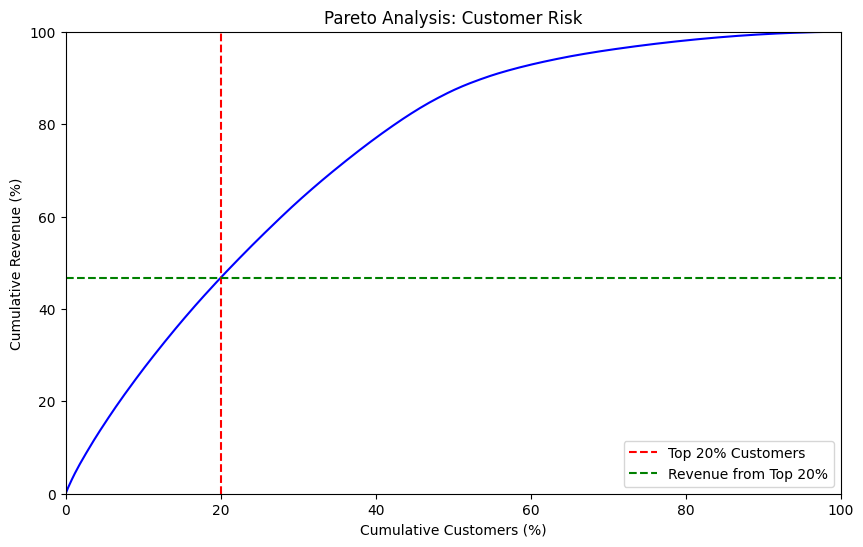

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Total Revenue per Customer
customer_sales = df.groupby('Customer ID')['Sales'].sum().reset_index()
customer_sales = customer_sales.sort_values(by='Sales', ascending=False)

# 2. Calculate Cumulative Percentages
customer_sales['Cumulative_Sales'] = customer_sales['Sales'].cumsum()
total_sales = customer_sales['Sales'].sum()
customer_sales['Cumulative_Sales_%'] = (customer_sales['Cumulative_Sales'] / total_sales) * 100

customer_sales['Customer_Rank'] = range(1, len(customer_sales) + 1)
total_customers = len(customer_sales)
customer_sales['Cumulative_Customer_%'] = (customer_sales['Customer_Rank'] / total_customers) * 100

# 3. Get exact revenue for top 20%
top_20_percent_data = customer_sales[customer_sales['Cumulative_Customer_%'] <= 20]
revenue_at_20_percent = top_20_percent_data['Cumulative_Sales_%'].max()

print(f"The Top 20% of customers generate {revenue_at_20_percent:.2f}% of the total revenue.")

# 4. SIMPLIFIED PLOTTING
plt.figure(figsize=(10, 6))

# Draw the line
sns.lineplot(data=customer_sales, x='Cumulative_Customer_%', y='Cumulative_Sales_%', color='blue')

# Draw the reference lines
plt.axvline(20, color='red', linestyle='--', label='Top 20% Customers')
plt.axhline(revenue_at_20_percent, color='green', linestyle='--', label='Revenue from Top 20%')

# Add basic text and limits
plt.title('Pareto Analysis: Customer Risk')
plt.xlabel('Cumulative Customers (%)')
plt.ylabel('Cumulative Revenue (%)')
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.legend()

plt.show()